# Agregation et Preparation des Donnees — Ligue 1
Ce notebook realise toutes les etapes de preparation du dataset final :
chargement, nettoyage, fusion, feature engineering et export.

## 1. Imports et configuration

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)

## 2. Chargement et concatenation des sources
Deux sources de donnees sont utilisees :
- **Part 1** : donnees issues de l'API Football (statistiques detaillees)
- **Part 2** : donnees issues de football-data.co.uk (cotes, resultats, stats de jeu)

Les saisons 2022/23, 2023/24 et 2024/25 sont chargees pour chaque source.

In [70]:
df_2022_2023_API = pd.read_csv("dataset/part1/ligue1_2022_completed.csv")
df_2023_2024_API = pd.read_csv("dataset/part1/ligue1_2023_completed.csv")
df_2024_2025_API = pd.read_csv("dataset/part1/ligue1_2024_completed.csv")

df_2022_2023 = pd.read_csv('dataset/part2/2022_2023.csv')
df_2023_2024 = pd.read_csv('dataset/part2/2023_2024.csv')
df_2024_2025 = pd.read_csv('dataset/part2/2024_2025.csv')
df_2025_2026 = pd.read_csv('dataset/part2/2025_2026.csv')

dataset1 = pd.concat([df_2022_2023_API, df_2023_2024_API, df_2024_2025_API])
dataset2 = pd.concat([df_2022_2023, df_2023_2024, df_2024_2025, df_2025_2026])

print(f"Dataset1 (API)     : {dataset1.shape}")
print(f"Dataset2 (externe) : {dataset2.shape}")

Dataset1 (API)     : (996, 40)
Dataset2 (externe) : (1225, 161)


## 3. Harmonisation des donnees
Avant la fusion, les deux sources doivent parler le meme langage :
dates au meme format, noms d'equipes identiques, colonnes renommees.

In [71]:
# Harmonisation des dates
dataset1['Date'] = pd.to_datetime(dataset1['fixture.date']).dt.date
dataset2['Date'] = pd.to_datetime(dataset2['Date'], dayfirst=True).dt.date

# Harmonisation des noms d'equipes
dataset2.replace(to_replace='Clermont',  value='Clermont Foot',  inplace=True)
dataset2.replace(to_replace='Troyes',    value='Estac Troyes',   inplace=True)
dataset2.replace(to_replace='Brest',     value='Stade Brestois', inplace=True)
dataset1.replace(to_replace='Saint Etienne',      value='St Etienne',     inplace=True)
dataset1.replace(to_replace='Paris Saint Germain', value='Paris SG',      inplace=True)
dataset1.replace(to_replace='Stade Brestois 29',   value='Stade Brestois', inplace=True)

# Renommage des colonnes dataset1
dataset1.rename(columns={
    'fixture.referee':     'Referee',
    'league.round':        'Round',
    'teams.home.name':     'HomeTeam',
    'teams.away.name':     'AwayTeam',
    'score.fulltime.home': 'HomeScore',
    'score.fulltime.away': 'AwayScore',
}, inplace=True)

# Renommage des colonnes dataset2
dataset2.rename(columns={
    'FTHG':'HomeScore', 'FTAG':'AwayScore',   'FTR':'Result',
    'HS':'HomeShot',    'AS':'AwayShot',
    'HST':'HomeShotTarget', 'AST':'AwayShotTarget',
    'HTHG':'HalftimeHomeGoals', 'HTAG':'HalftimeAwayGoals', 'HTR':'HalftimeResult',
    'HF':'HomeTeamFouls',  'AF':'AwayTeamFouls',
    'HC':'HomeTeamCorners','AC':'AwayTeamCorners',
    'HY':'HomeYellowCards','AY':'AwayYellowCards',
    'HR':'HomeRedCards',   'AR':'AwayRedCards',
}, inplace=True)

## 4. Fusion des deux datasets
La fusion se fait sur les cles communes : date, equipes et score.
On utilise un `outer join` pour conserver tous les matchs, meme ceux presents dans une seule source.

In [72]:
merged_df = pd.merge(
    dataset1, dataset2,
    left_on=['Date','HomeTeam','AwayTeam','HomeScore','AwayScore'],
    right_on=['Date','HomeTeam','AwayTeam','HomeScore','AwayScore'],
    how='outer'
)
print(f'Dataset fusionne : {merged_df.shape}')
merged_df.head()

Dataset fusionne : (1229, 197)


,fixture.id,Referee,fixture.timezone,fixture.date,fixture.timestamp,fixture.periods.first,fixture.periods.second,fixture.venue.id,fixture.venue.name,fixture.venue.city,fixture.status.long,fixture.status.short,fixture.status.elapsed,fixture.status.extra,league.id,league.name,league.country,league.logo,league.flag,league.season,Round,league.standings,teams.home.id,HomeTeam,teams.home.logo,teams.home.winner,teams.away.id,AwayTeam,teams.away.logo,teams.away.winner,goals.home,goals.away,score.halftime.home,score.halftime.away,HomeScore,AwayScore,score.extratime.home,score.extratime.away,score.penalty.home,score.penalty.away,Date,Div,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA
0,871474.0,B. Bastien,UTC,2022-08-05T19:00:00+00:00,1.659726e+09,1.659726e+09,1.659730e+09,666.0,Groupama Stadium,Décines-Charpieu,Match Finished,FT,90.0,NaN,61.0,Ligue 1,France,https://media.api-sports.io/football/leagues/6...,https://media.api-sports.io/flags/fr.svg,2022.0,Regular Season - 1,True,80.0,Lyon,https://media.api-sports.io/football/teams/80.png,True,98.0,Ajaccio,https://media.api-sports.io/football/teams/98.png,False,2.0,1.0,2.0,1.0,2,1,NaN,NaN,NaN,NaN,2022-08-05,F1,20:00,H,2.0,1.0,H,11.0,8.0,6.0,4.0,10.0,18.0,4.0,3.0,1.0,6.0,1.0,1.0,1.33,5.25,8.50,1.33,5.25,8.00,1.35,5.25,9.00,1.33,5.53,10.75,1.30,5.25,10.00,1.30,5.25,11.00,1.36,5.70,11.00,1.32,5.35,9.65,1.66,2.20,1.70,2.26,1.74,2.31,1.68,2.21,-1.50,2.00,1.93,2.01,1.91,2.04,1.94,1.97,1.89,1.33,5.00,8.50,1.35,5.25,7.50,1.35,5.25,8.50,1.38,5.31,8.68,1.33,4.8,9.5,1.33,5.0,9.50,1.38,5.70,10.00,1.34,5.21,8.96,1.66,2.20,1.70,2.27,1.72,2.47,1.64,2.27,-1.50,2.08,1.85,2.12,1.81,2.12,1.96,2.01,1.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,871472.0,J. Stinat,UTC,2022-08-06T19:00:00+00:00,1.659812e+09,1.659812e+09,1.659816e+09,644.0,Stade Gabriel Montpied,Clermont-Ferrand,Match Finished,FT,90.0,NaN,61.0,Ligue 1,France,https://media.api-sports.io/football/leagues/6...,https://media.api-sports.io/flags/fr.svg,2022.0,Regular Season - 1,True,99.0,Clermont Foot,https://media.api-sports.io/football/teams/99.png,False,85.0,Paris SG,https://media.api-sports.io/football/teams/85.png,True,0.0,5.0,0.0,3.0,0,5,NaN,NaN,NaN,NaN,2022-08-06,F1,20:00,A,0.0,3.0,A,7.0,18.0,1.0,12.0,13.0,13.0,0.0,6.0,2.0,1.0,0.0,0.0,9.50,6.50,1.25,10.00,6.50,1.25,10.00,6.50,1.25,9.88,6.81,1.28,11.00,6.00,1.24,11.50,6.50,1.22,11.50,7.00,1.30,10.06,6.53,1.26,1.40,3.00,1.41,3.04,1.43,3.25,1.38,3.00,1.75,1.99,1.94,1.95,1.95,2.01,1.95,1.96,1.90,13.00,7.00,1.20,13.00,7.00,1.21,11.00,6.75,1.25,13.32,6.77,1.24,13.00,6.5,1.2,13.00,7.0,1.20,14.50,7.40,1.29,12.17,6.67,1.23,1.40,3.00,1.45,2.85,1.47,3.00,1.42,2.87,2.00,1.94,1.99,1.93,1.98,1.95,2.17,1.83,2.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

## 5. Nettoyage
Suppression des colonnes inutiles (metadonnees API, cotes redondantes) et nettoyage du numero de journee.

In [73]:
merged_df['Round'] = merged_df['Round'].str.replace('Regular Season - ', '')
merged_df['Round'] = merged_df['Round'].str.replace('Relegation Round', '35')

merged_df.drop([
    'fixture.id','fixture.timezone','fixture.date','fixture.timestamp',
    'fixture.periods.first','fixture.periods.second',
    'fixture.venue.id','fixture.venue.name','fixture.venue.city',
    'fixture.status.long','fixture.status.short','fixture.status.elapsed','fixture.status.extra',
    'league.id','league.name','league.country','league.logo','league.flag','league.standings',
    'teams.home.id','teams.home.logo','teams.away.id','teams.home.winner',
    'teams.away.logo','teams.away.winner','Div',
    'score.penalty.home','score.penalty.away','score.extratime.home','score.extratime.away',
    'goals.home','goals.away','score.halftime.home','score.halftime.away',
    'LBCA','LBCD','LBCH','CLCA','CLCD','CLCH','LBA','CLH','CLD','LBH','LBD','CLA',
    'BMGMCH','BVA','BFDH','BFDD','BFDA','BFDCA','BMGMD','BMGMA','BVH','BVD','BMGMH',
    'BVCA','BVCH','BMGMCA','BMGMCD','BFDCH','BFDCD','BVCD','1XBA','1XBH','1XBD',
    '1XBCH','BFCA','BFCD','BFCH','BFD','BFA','BFH','1XBCA','1XBCD',
    'IWD','IWA','IWCH','IWCD','IWCA','IWH',
    'BFE<2.5','BFE>2.5','BFEAHA','BFEAHH','BFED','BFEH','BFECAHA','BFEA','BFECA',
    'BFECAHH','BFECH','BFEC>2.5','BFEC<2.5','BFECD',
    'VCA','VCD','VCH','VCCH','VCCA','VCCD','WHA','WHD','WHH','WHCD','WHCH','WHCA',
], axis=1, inplace=True)
print(f'Apres nettoyage : {merged_df.shape}')

Apres nettoyage : (1229, 89)


## 6. Valeurs manquantes
Analyse et traitement des valeurs manquantes restantes.

In [74]:
missing_values  = merged_df.isnull().sum()
missing_percent = (missing_values / len(merged_df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing_values.index,
    'Valeurs manquantes': missing_values.values,
    'Pourcentage': missing_percent.values
})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Pourcentage', ascending=False)
print(missing_df)

# La saison 2025/26 n'est pas encore complete dans l'API
merged_df['league.season'] = merged_df['league.season'].fillna('2025')

              Colonne  Valeurs manquantes  Pourcentage
0             Referee                 233    18.958503
1       league.season                 233    18.958503
2               Round                 233    18.958503
28                BWH                 130    10.577705
60               BWCH                 130    10.577705
30                BWA                 130    10.577705
62               BWCA                 130    10.577705
61               BWCD                 130    10.577705
29                BWD                 130    10.577705
43              P<2.5                  91     7.404394
42              P>2.5                  91     7.404394
74             PC>2.5                  89     7.241660
75             PC<2.5                  89     7.241660
32                PSD                  84     6.834825
31                PSH                  84     6.834825
52               PAHA                  84     6.834825
51               PAHH                  84     6.834825
65        

### Imputation des valeurs manquantes — Cotes bookmakers

Certaines colonnes de cotes (Betway, Pinnacle) contiennent des valeurs manquantes
pour les matchs où ces bookmakers ne proposaient pas de cote.

On remplace ces valeurs par la **médiane** de chaque colonne, ce qui est plus robuste
que la moyenne car elle n'est pas influencée par les valeurs extrêmes.

In [75]:
# Imputation par la médiane des données manquantes

features_to_replace = {'BWH', 'BWD', 'BWA', 'PSH', 'PSD', 'PSA', 
                        'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 
                        'BWCH', 'BWCD', 'BWCA', 'PSCH', 'PSCD', 'PSCA', 
                        'PC>2.5', 'PC<2.5', 'PCAHH', 'PCAHA'}

for feat in features_to_replace:
    median = merged_df[feat].median()
    merged_df[feat] = merged_df[feat].fillna(median)

### Supréssion des résultats manquants

In [76]:
# Suppression des lignes sans résultat
merged_df = merged_df.dropna(subset=['Result'])
print(f"Lignes supprimées : {len(merged_df) - len(merged_df)}")
print(f"Dataset final     : {merged_df.shape}")

Lignes supprimées : 0
Dataset final     : (1225, 89)


## 7. Enrichissement avec les donnees arbitres
Un fichier externe contenant les arbitres manquants est fusionne pour completer la colonne `Referee`.

In [77]:
referees_df = pd.read_csv('dataset/referees_list.csv')
referees_df['Round'] = referees_df['Round'].astype(str)
referees_df['Date']  = pd.to_datetime(referees_df['Date']).dt.date

final_df = pd.merge(
    merged_df, referees_df,
    left_on=['Date','HomeTeam'],
    right_on=['Date','HomeTeam'],
    how='left', suffixes=('','_new')
)

final_df['Referee'] = final_df['Referee'].fillna(final_df['Referee_new'])
final_df['Round']   = final_df['Round'].fillna(final_df['Round_new'])
final_df.drop(['Referee_new','Round_new'], axis=1, inplace=True)
final_df['Round'] = final_df['Round'].astype(int)

print(f'Dataset final : {final_df.shape}')

Dataset final : (1225, 89)


## 8. Analyse exploratoire
Visualisation des distributions, des performances par equipe et de l'influence de l'arbitre.

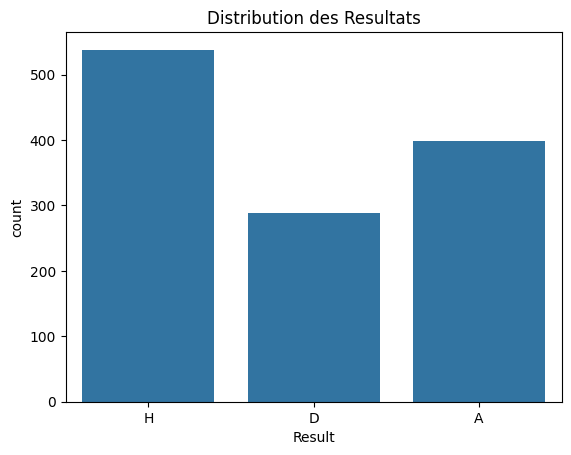

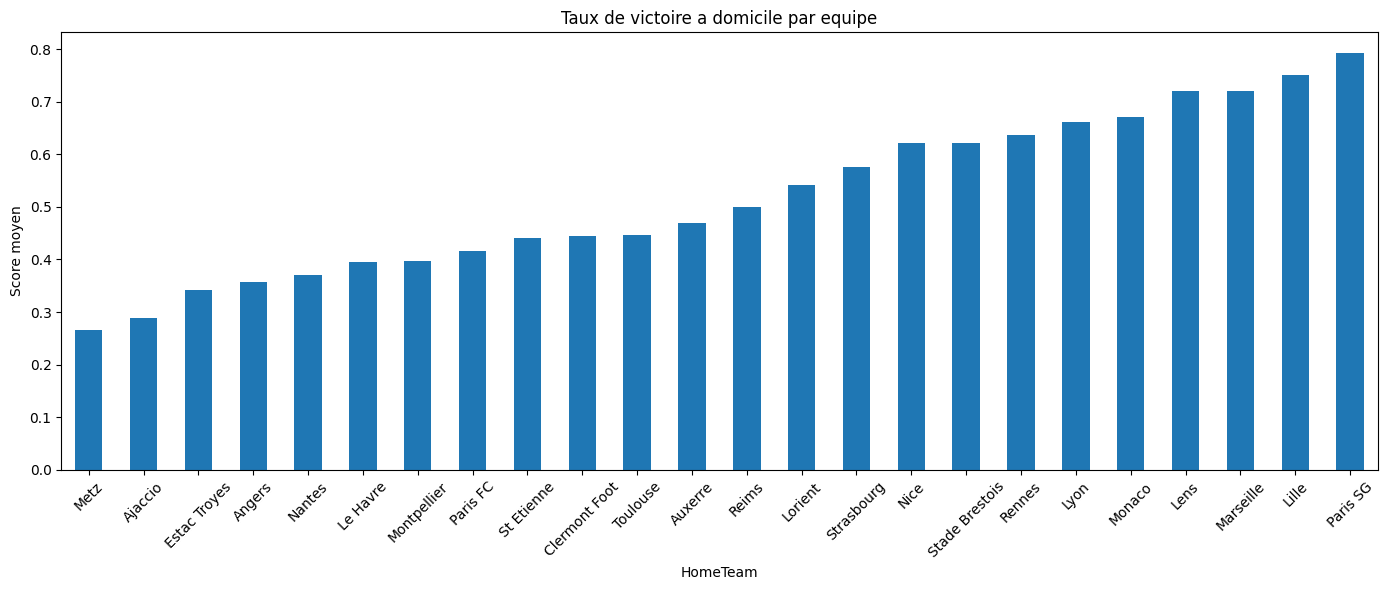

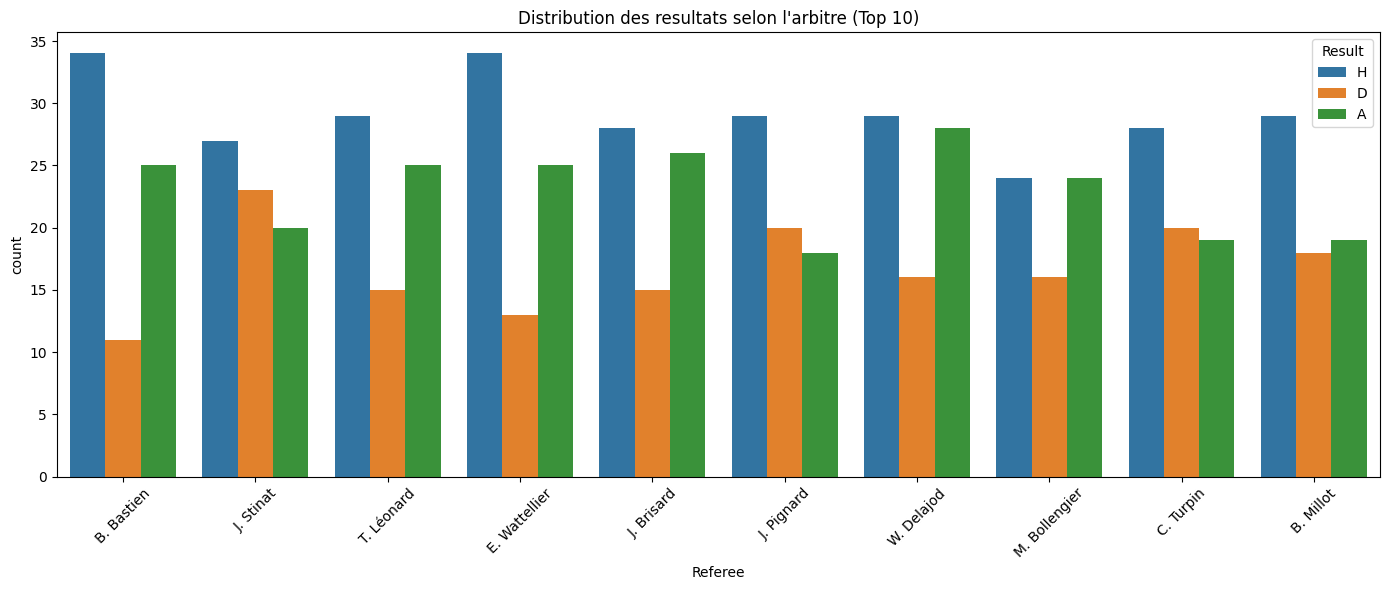

In [78]:
# Distribution des resultats
sns.countplot(data=final_df, x='Result', order=['H','D','A'])
plt.title('Distribution des Resultats')
plt.show()

# Taux de victoire a domicile par equipe
final_df['result_home'] = final_df['Result'].map({'H':1,'D':0.5,'A':0})
final_df['result_away'] = final_df['Result'].map({'H':0,'D':0.5,'A':1})
final_df['result_num']  = final_df['Result'].map({'H':1,'D':0,'A':-1})

plt.figure(figsize=(14,6))
final_df.groupby('HomeTeam')['result_home'].mean().sort_values().plot(
    kind='bar', title='Taux de victoire a domicile par equipe', ylabel='Score moyen')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top 10 arbitres
top_10 = final_df['Referee'].value_counts().head(10).index
plt.figure(figsize=(14,6))
sns.countplot(data=final_df[final_df['Referee'].isin(top_10)], x='Referee', hue='Result', hue_order=['H','D','A'])
plt.title("Distribution des resultats selon l'arbitre (Top 10)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Feature engineering — Moyennes de buts par equipe / saison
Ces features sont **connues avant le match** : elles representent l'historique de la saison en cours.
Elles seront utilisees comme variables predictives dans le modele ML.

In [79]:
home_goals = final_df.groupby(['league.season','HomeTeam']).agg(
    goals_scored_home=('HomeScore','sum'),
    goals_conceded_home=('AwayScore','sum'),
    games_home=('HomeScore','count')
).reset_index().rename(columns={'HomeTeam':'Team'})

away_goals = final_df.groupby(['league.season','AwayTeam']).agg(
    goals_scored_away=('AwayScore','sum'),
    goals_conceded_away=('HomeScore','sum'),
    games_away=('AwayScore','count')
).reset_index().rename(columns={'AwayTeam':'Team'})

goals_df = pd.merge(home_goals, away_goals, on=['league.season','Team'])
goals_df['total_goals_scored']   = goals_df['goals_scored_home']   + goals_df['goals_scored_away']
goals_df['total_goals_conceded'] = goals_df['goals_conceded_home'] + goals_df['goals_conceded_away']
goals_df['total_games']          = goals_df['games_home'] + goals_df['games_away']
goals_df['avg_goals_scored']     = (goals_df['total_goals_scored']   / goals_df['total_games']).round(3)
goals_df['avg_goals_conceded']   = (goals_df['total_goals_conceded'] / goals_df['total_games']).round(3)

avg_goals = goals_df[['league.season','Team','avg_goals_scored','avg_goals_conceded']]

## 10. Feature engineering — Classement final par saison
Le classement est calcule sur la base des points, de la difference de buts et des buts marques.
Il sert de proxy pour la force relative de chaque equipe dans la saison.

In [80]:
def home_points(result): return 3 if result == 'H' else (1 if result == 'D' else 0)
def away_points(result): return 3 if result == 'A' else (1 if result == 'D' else 0)

home_rank = final_df.groupby(['league.season','HomeTeam']).apply(lambda g: pd.Series({
    'games':  len(g),
    'wins':   (g['Result']=='H').sum(), 'draws':  (g['Result']=='D').sum(), 'losses': (g['Result']=='A').sum(),
    'points': g['Result'].apply(home_points).sum(),
    'goals_for': g['HomeScore'].sum(), 'goals_against': g['AwayScore'].sum(),
})).reset_index().rename(columns={'HomeTeam':'Team'})

away_rank = final_df.groupby(['league.season','AwayTeam']).apply(lambda g: pd.Series({
    'games':  len(g),
    'wins':   (g['Result']=='A').sum(), 'draws':  (g['Result']=='D').sum(), 'losses': (g['Result']=='H').sum(),
    'points': g['Result'].apply(away_points).sum(),
    'goals_for': g['AwayScore'].sum(), 'goals_against': g['HomeScore'].sum(),
})).reset_index().rename(columns={'AwayTeam':'Team'})

standings = pd.concat([home_rank, away_rank]).groupby(['league.season','Team']).sum().reset_index()
standings['goal_difference'] = standings['goals_for'] - standings['goals_against']
standings = standings.sort_values(['league.season','points','goal_difference','goals_for'],
                                   ascending=[True,False,False,False])
standings['season_rank'] = standings.groupby('league.season').cumcount() + 1

final_standings = standings[['league.season','Team','season_rank',
                              'points','wins','draws','losses',
                              'goals_for','goals_against','goal_difference']]
print(final_standings[final_standings['league.season']==2022].head(5).to_string(index=False))

league.season      Team  season_rank  points  wins  draws  losses  goals_for  goals_against  goal_difference
       2022.0  Paris SG            1      85    27      4       7         89             40               49
       2022.0      Lens            2      84    25      9       4         68             29               39
       2022.0 Marseille            3      73    22      7       9         67             40               27
       2022.0    Rennes            4      68    21      5      12         69             39               30
       2022.0     Lille            5      67    19     10       9         65             44               21


## 11. Insertion des features dans le dataset
Le mapping direct (saison, equipe) -> valeur est utilise pour inserer les features sans risque de doublons.

In [81]:
avg_scored   = avg_goals.set_index(['league.season','Team'])['avg_goals_scored']
avg_conceded = avg_goals.set_index(['league.season','Team'])['avg_goals_conceded']
rank_map     = final_standings.set_index(['league.season','Team'])['season_rank']

final_df['home_avg_goals_scored']   = final_df.set_index(['league.season','HomeTeam']).index.map(avg_scored)
final_df['home_avg_goals_conceded'] = final_df.set_index(['league.season','HomeTeam']).index.map(avg_conceded)
final_df['home_season_rank']        = final_df.set_index(['league.season','HomeTeam']).index.map(rank_map)
final_df['away_avg_goals_scored']   = final_df.set_index(['league.season','AwayTeam']).index.map(avg_scored)
final_df['away_avg_goals_conceded'] = final_df.set_index(['league.season','AwayTeam']).index.map(avg_conceded)
final_df['away_season_rank']        = final_df.set_index(['league.season','AwayTeam']).index.map(rank_map)

new_cols = ['home_avg_goals_scored','home_avg_goals_conceded','home_season_rank',
            'away_avg_goals_scored','away_avg_goals_conceded','away_season_rank']
print('Valeurs manquantes :', final_df[new_cols].isnull().sum().sum())

Valeurs manquantes : 0


## 12. Matrice de correlation
Analyse des correlations entre les variables numeriques.

> Les colonnes `HomeScore` et `AwayScore` sont incluses ici uniquement pour l'exploration — elles ne seront pas utilisees dans le modele predictif (data leakage).

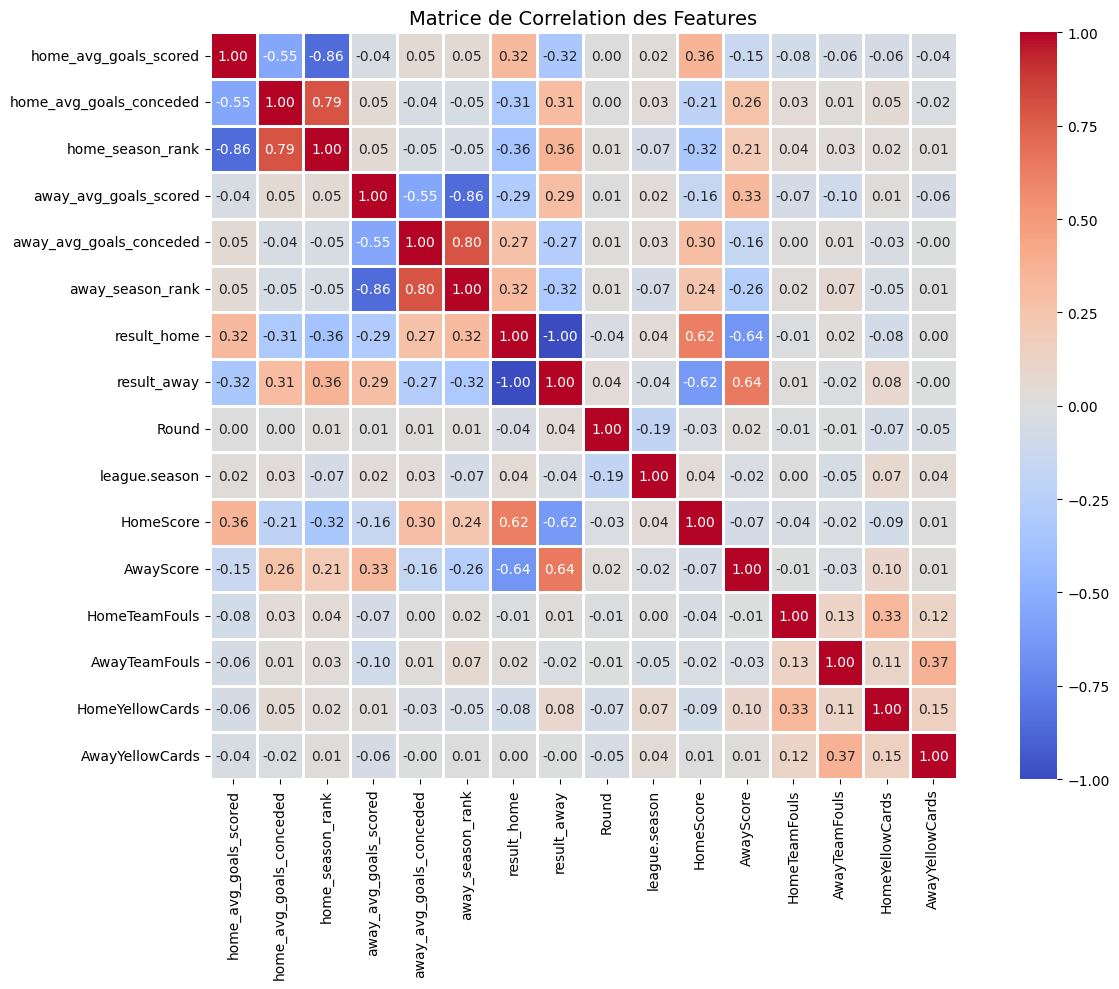

In [82]:
numerical_features = final_df[[
    'home_avg_goals_scored','home_avg_goals_conceded','home_season_rank',
    'away_avg_goals_scored','away_avg_goals_conceded','away_season_rank',
    'result_home','result_away','Round','league.season',
    'HomeScore','AwayScore','HomeTeamFouls','AwayTeamFouls',
    'HomeYellowCards','AwayYellowCards',
]]

correlation_matrix = numerical_features.corr()
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matrice de Correlation des Features', fontsize=14)
plt.tight_layout()
plt.show()

In [84]:
# missing_values  = final_df.isnull().sum()
# print(missing_values)

Referee                    0
league.season              0
Round                      0
HomeTeam                   0
AwayTeam                   0
HomeScore                  0
AwayScore                  0
Date                       0
Time                       0
Result                     0
HalftimeHomeGoals          0
HalftimeAwayGoals          0
HalftimeResult             0
HomeShot                   0
AwayShot                   0
HomeShotTarget             0
AwayShotTarget             0
HomeTeamFouls              0
AwayTeamFouls              0
HomeTeamCorners            0
AwayTeamCorners            0
HomeYellowCards            0
AwayYellowCards            0
HomeRedCards               0
AwayRedCards               0
B365H                      0
B365D                      0
B365A                      0
BWH                        0
BWD                        0
BWA                        0
PSH                        0
PSD                        0
PSA                        0
MaxH          

## 13. Export du dataset final

In [83]:
final_df.to_csv("dataset/completed_match_dataset.csv")
print(f"Fichier exporte : {final_df.shape[0]} lignes, {final_df.shape[1]} colonnes")
final_df.head()

Fichier exporte : 1225 lignes, 98 colonnes


,Referee,league.season,Round,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,result_home,result_away,result_num,home_avg_goals_scored,home_avg_goals_conceded,home_season_rank,away_avg_goals_scored,away_avg_goals_conceded,away_season_rank
0,B. Bastien,2022.0,1,Lyon,Ajaccio,2,1,2022-08-05,20:00,H,2.0,1.0,H,11.0,8.0,6.0,4.0,10.0,18.0,4.0,3.0,1.0,6.0,1.0,1.0,1.33,5.25,8.50,1.33,5.25,8.00,1.33,5.53,10.75,1.36,5.70,11.00,1.32,5.35,9.65,1.66,2.20,1.70,2.26,1.74,2.31,1.68,2.21,-1.50,2.00,1.93,2.01,1.91,2.04,1.94,1.97,1.89,1.33,5.00,8.50,1.35,5.25,7.50,1.38,5.31,8.68,1.38,5.70,10.00,1.34,5.21,8.96,1.66,2.20,1.70,2.27,1.72,2.47,1.64,2.27,-1.50,2.08,1.85,2.12,1.81,2.12,1.96,2.01,1.86,1.0,0.0,1,1.711,1.237,7,0.605,1.947,18
1,J. Stinat,2022.0,1,Clermont Foot,Paris SG,0,5,2022-08-06,20:00,A,0.0,3.0,A,7.0,18.0,1.0,12.0,13.0,13.0,0.0,6.0,2.0,1.0,0.0,0.0,9.50,6.50,1.25,10.00,6.50,1.25,9.88,6.81,1.28,11.50,7.00,1.30,10.06,6.53,1.26,1.40,3.00,1.41,3.04,1.43,3.25,1.38,3.00,1.75,1.99,1.94,1.95,1.95,2.01,1.95,1.96,1.90,13.00,7.00,1.20,13.00,7.00,1.21,13.32,6.77,1.24,14.50,7.40,1.29,12.17,6.67,1.23,1.40,3.00,1.45,2.85,1.47,3.00,1.42,2.87,2.00,1.94,1.99,1.93,1.98,1.95,2.17,1.83,2.02,0.0,1.0,-1,1.184,1.289,8,2.342,1.053,1
2,F. Letexier,2022.0,1,Strasbourg,Monaco,1,2,2022-08-06,16:00,A,0.0,1.0,A,11.0,24.0,7.0,11.0,18.0,15.0,3.0,7.0,0.0,2.0,0.0,0.0,2.62,3.25,2.75,2.60,3.30,2.70,2.64,3.40,2.86,2.70,3.56,2.92,2.60,3.36,2.75,2.03,1.87,2.07,1.85,2.09,1.98,1.97,1.85,0.00,1.91,2.02,1.88,2.05,1.93,2.06,1.88,2.00,2.30,3.20,3.20,2.40,3.20,3.00,2.42,3.35,3.26,2.62,3.52,3.28,2.43,3.23,3.08,2.20,1.66,2.12,1.79,2.22,1.98,2.12,1.74,-0.25,2.03,1.90,2.07,1.87,2.13,1.90,2.06,1.82,0.0,1.0,-1,1.342,1.553,15,1.842,1.526,6
3,H. Ben El Hadj,2022.0,1,Angers,Nantes,0,0,2022-08-07,14:00,D,0.0,0.0,D,16.0,14.0,6.0,4.0,15.0,13.0,3.0,6.0,3.0,3.0,0.0,0.0,2.70,3.25,2.70,2.65,3.20,2.70,2.82,3.29,2.75,2.84,3.30,2.82,2.73,3.22,2.71,2.10,1.72,2.23,1.72,2.23,1.80,2.13,1.72,0.00,1.97,1.96,1.99,1.93,1.99,1.98,1.94,1.92,3.00,3.25,2.37,3.10,3.10,2.40,3.22,3.28,2.46,3.29,3.35,2.50,3.11,3.21,2.41,2.20,1.66,2.23,1.72,2.24,1.76,2.17,1.70,0.25,1.85,2.08,1.83,2.09,1.87,2.12,1.81,2.07,0.5,0.5,0,0.868,2.132,20,0.974,1.447,16
4,T. Léonard,2022.0,1,Lens,Stade Brestois,3,2,2022-08-07,14:00,H,1.0,0.0,H,17.0,6.0,7.0,4.0,16.0,14.0,6.0,3.0,2.0,4.0,0.0,0.0,1.57,4.33,5.25,1.53,4.40,5.75,1.60,4.60,5.51,1.60,4.70,6.00,1.56,4.43,5.54,1.66,2.20,1.69,2.28,1.73,2.31,1.66,2.23,-1.00,1.98,1.95,1.99,1.93,1.99,1.97,1.93,1.92,1.60,4.20,5.25,1.62,3.90,5.50,1.62,4.23,5.81,1.65,4.30,5.90,1.61,4.07,5.53,1.89,2.01,1.87,2.05,1.90,2.12,1.83,1.99,-1.00,2.07,1.86,2.10,1.83,2.13,1.87,2.07,1.81,1.0,0.0,1,1.789,0.763,2,1.158,1.421,14
